In [7]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np

%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


# Load the dataset
df = pd.read_csv('superstore_sales.csv', encoding='latin1')

print(df.head())    
print(df.columns.tolist())



   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Product_ID         Cat

In [8]:
df


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [ ]:
# This Begins Project 1 of week 2. 

# Time series & category charts
# Plot sales over time (line charts) and  monthly/quarterly aggregation.
# Use bar charts to compare categories and pie charts for share.
# Save charts to PNG and export a short summary.
# Discuss chart choice and label/legend/axis formatting

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime


#background settings

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option('display.float_format','{:,.2f}'.format)

#We will now load the CSV file

FilePath = 'superstore_sales.csv'

df = pd.read_csv(FilePath , encoding='latin1')

print(f"Loading date from {FilePath}")

print(f"shape: {df.shape[0]}:rows * {df.shape[1]} columns")
print(f"Date Range: {df ['Order_Date'].min() } to {df ['Order_Date'].max()}" )
print(f"Total Sales: ${df['Sales'].sum():,.2f}\n")




Loading date from superstore_sales.csv
shape: 9800:rows * 18 columns
Date Range: 1/1/2018 to 9/9/2018
Total Sales: $2,261,536.78



In [ ]:
#Data Preparation 
#Convert Dates to handle all formats

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst = False)

#Creating Useful Time Columns

df["Year"] = df['Order_Date'].dt.year
df["Month"] = df['Order_Date'].dt.to_period('M')
df['Quarter']= df['Order_Date'].dt.to_period('Q')
df['Month_Year']= df['Order_Date'].dt.strftime('%Y-%m')
        
print("Data Preparation completed.\n")




Data Preparation completed.



In [18]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Year,Month,Quarter,Month_Year
0,1,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,"2,017.00",2017-08,2017Q3,2017-08
1,2,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,"2,017.00",2017-08,2017Q3,2017-08
2,3,CA-2017-138688,2017-12-06,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,"2,017.00",2017-12,2017Q4,2017-12
3,4,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,"2,016.00",2016-11,2016Q4,2016-11
4,5,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.37,"2,016.00",2016-11,2016Q4,2016-11


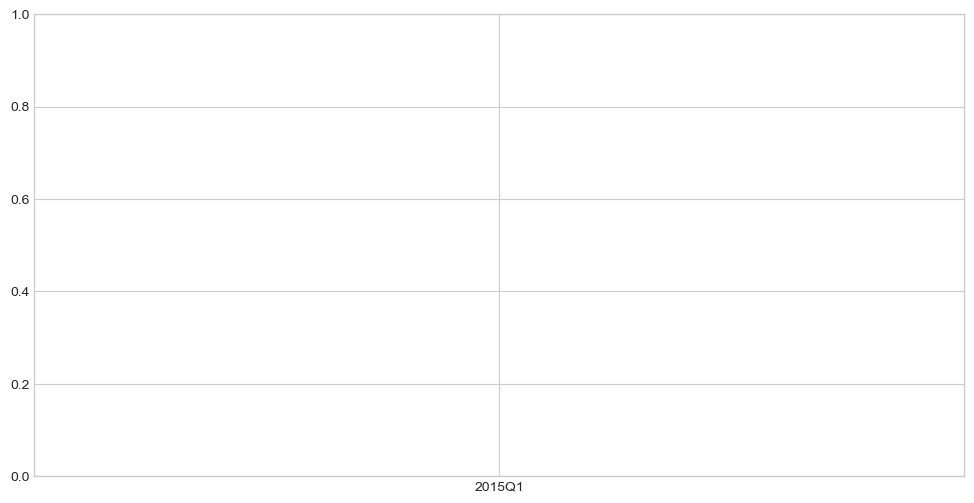

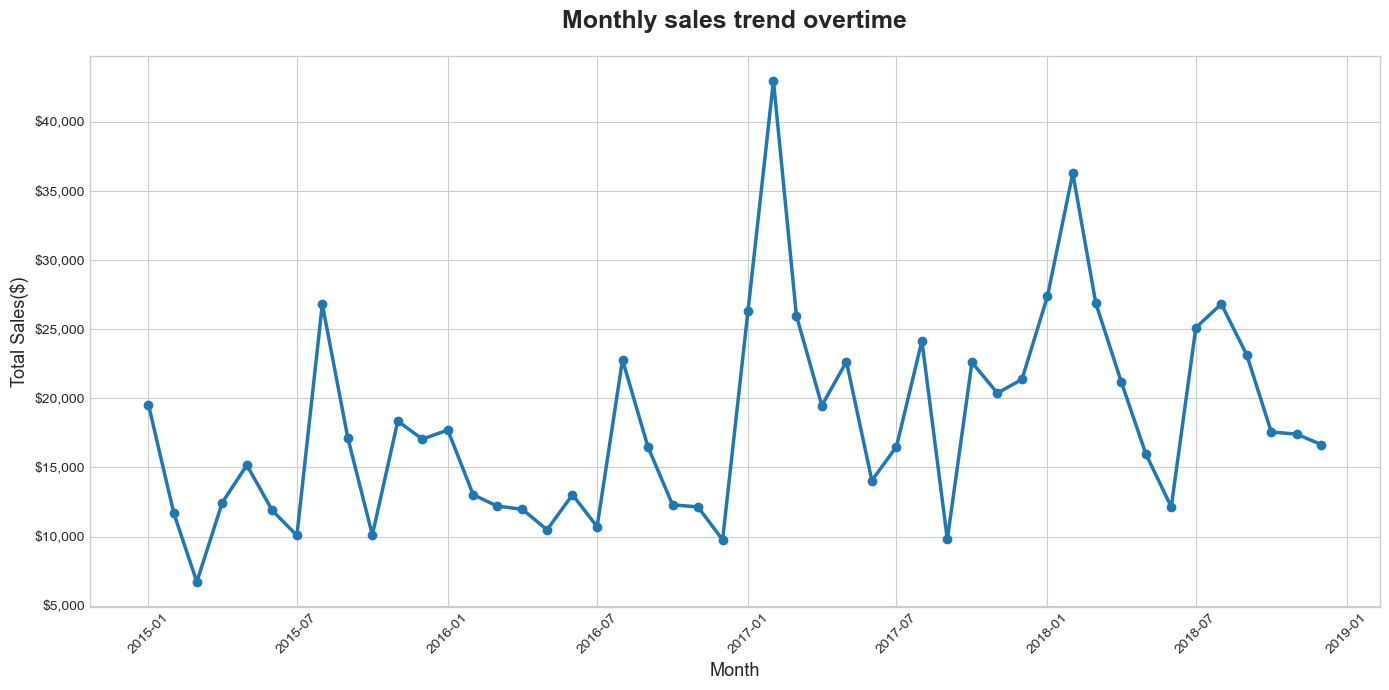

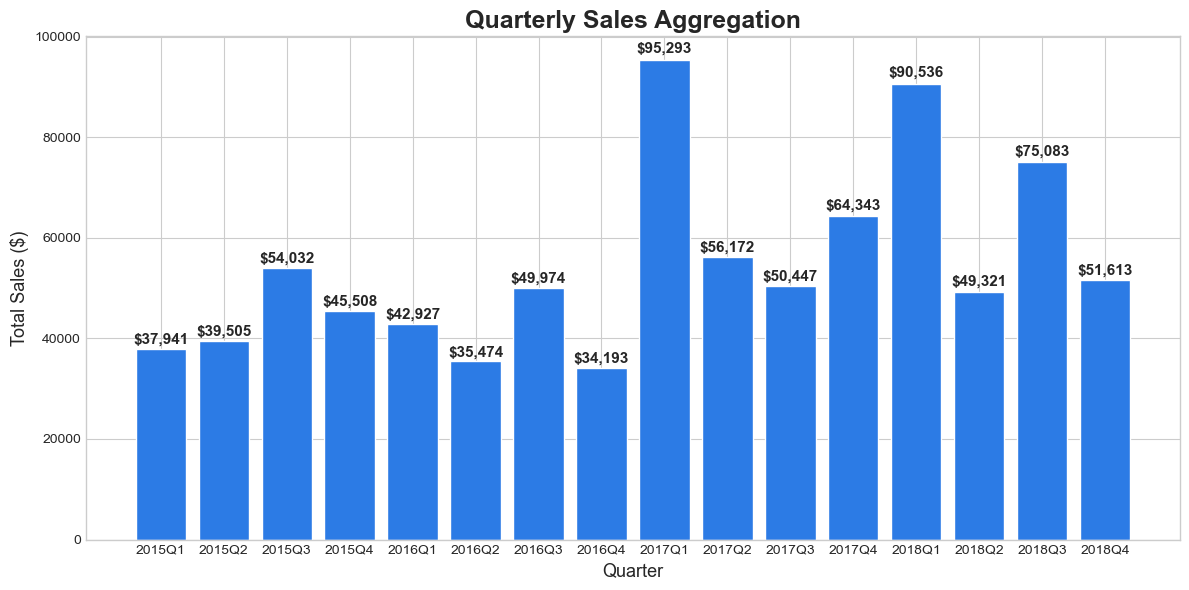

In [ ]:
#Time Series analysis 

Monthly_Sales = df.groupby("Month_Year")['Sales'].sum().reset_index()
Monthly_Sales['Month_Year'] = pd.to_datetime(Monthly_Sales['Month_Year'])

#Line Chart: Sales Trend over a monthly basis 

plt.figure(figsize=(14,7))
plt.plot(Monthly_Sales['Month_Year'],Monthly_Sales['Sales'],marker = "o", linewidth = 2.5, markersize = 6 , color = "#1f77b4")

plt.title("Monthly sales trend overtime", fontsize = 18,  fontweight = "bold", pad= 20)

plt.xlabel("Month", fontsize= 13)

plt.ylabel("Total Sales($)", fontsize = 13)
plt.xticks(rotation = 45)

#Format y-axis with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()


#Quarterly Sales Bar Chart
quarterly_sales = df.groupby('Quarter')['Sales'].sum().reset_index()
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(12,6))
bars = plt.bar(quarterly_sales['Quarter'],quarterly_sales['Sales'],color = '#2c7be5')
plt.title('Quarterly Sales Aggregation', fontsize=18, fontweight='bold')
plt.xlabel('Quarter', fontsize=13)
plt.ylabel('Total Sales ($)', fontsize=13)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.01, f'${height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('Quarterly_Sales.png',dpi=300,bbox_inches="tight")
plt.show()








<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

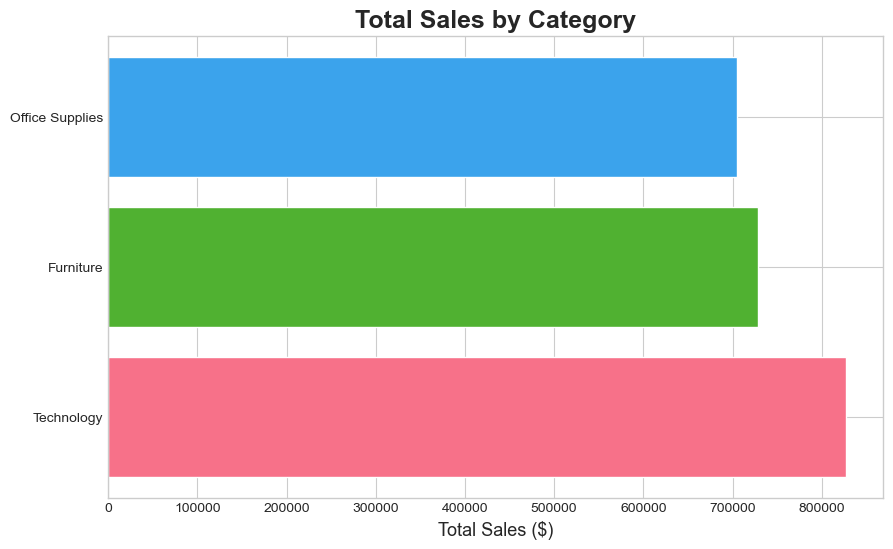

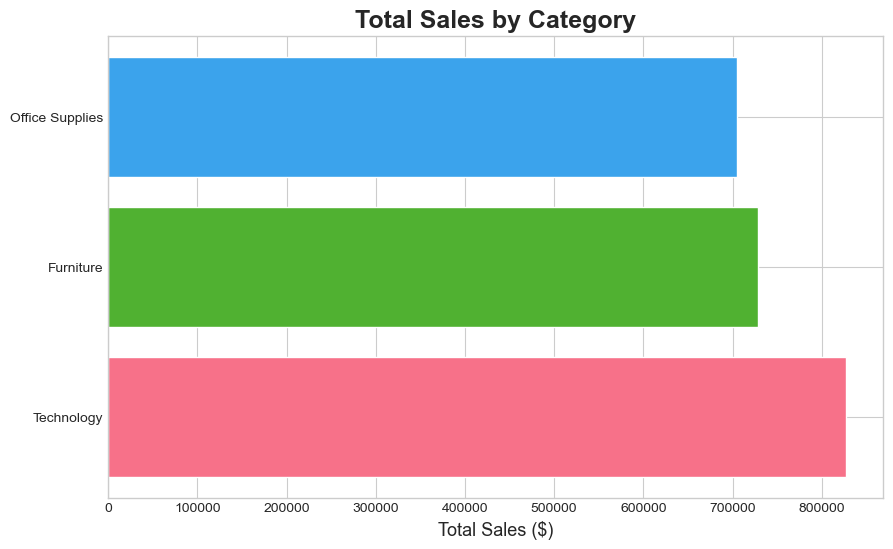

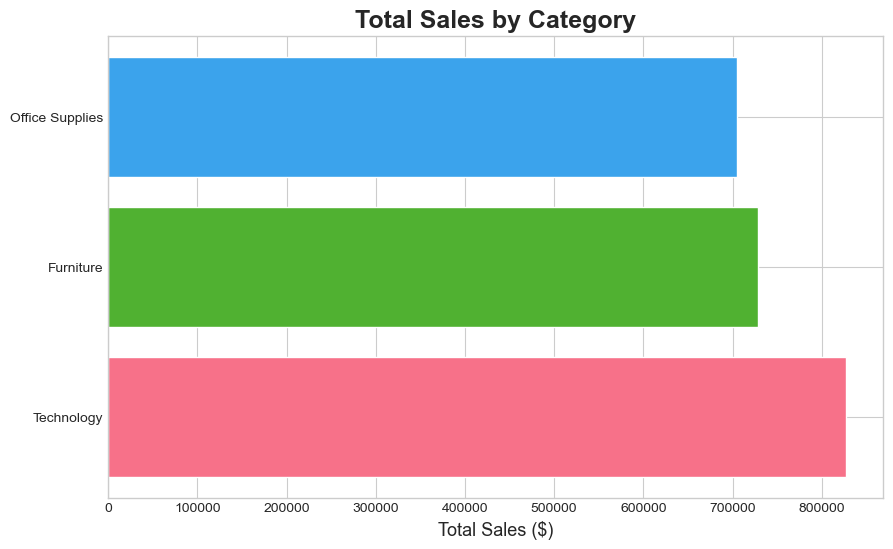

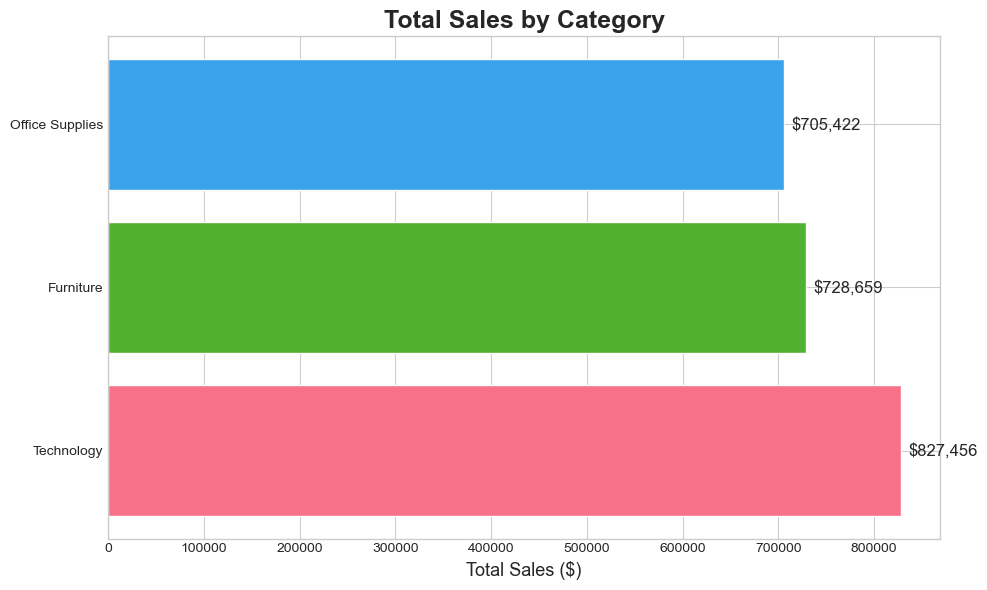

In [30]:
#Category Anaysis 
category_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).reset_index()

plt.figure(figsize = (10,6))
bars = plt.barh(category_sales['Category'], category_sales['Sales'], color =sns.color_palette("husl",len(category_sales)))

plt.title('Total Sales by Category', fontsize = 18, fontweight = "bold")
plt.xlabel('Total Sales ($)', fontsize = 13)

for i, v in enumerate(category_sales['Sales']):
    plt.text(v + max(category_sales['Sales'])*0.01, i, f'${v:,.0f}', va = 'center', fontsize = 12)
plt.tight_layout()
plt.savefig('Sales_by_category.png', dpi = 300, bbox_inches = 'tight')
plt.show()



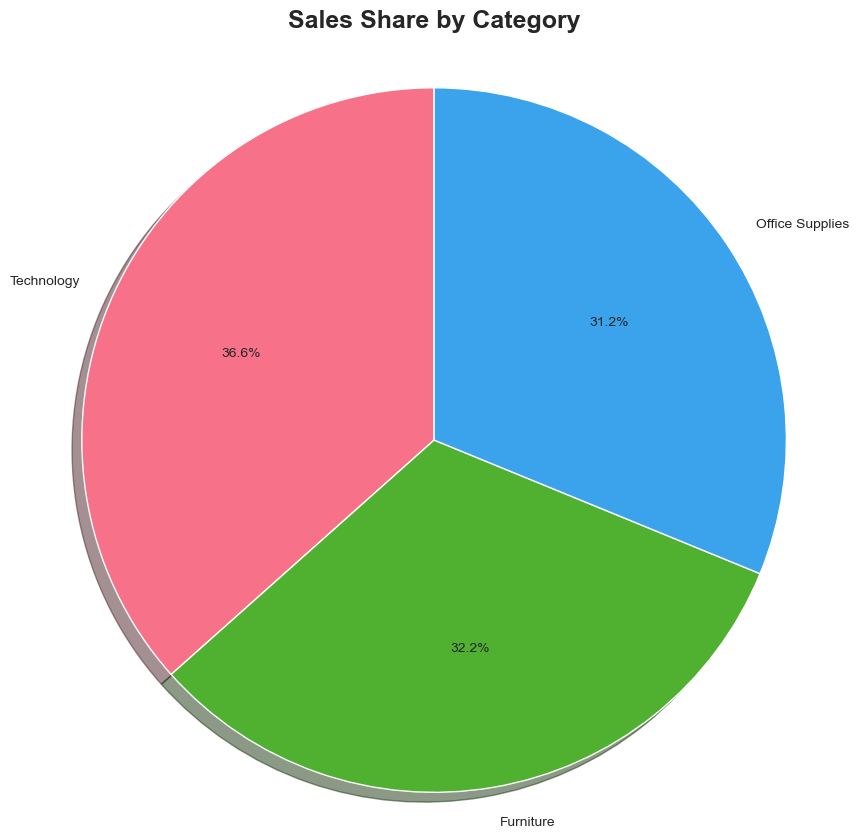

In [31]:
if len(category_sales) <= 8:
    plt.figure(figsize=(10,10))
    plt.pie(category_sales['Sales'], labels = category_sales['Category'],autopct = '%1.1f%%', startangle = 90, shadow = True, colors = sns.color_palette("husl", len(category_sales)))
    plt.title('Sales Share by Category', fontsize = 18, fontweight='bold', pad = 20)
    plt.axis('equal')
    plt.show()


In [32]:
total_sales = df['Sales'].sum()
top_category = category_sales.iloc[0]

print("\n" + "="*60)
print("🔥 SALES DATA ANALYSIS SUMMARY")
print("="*60)
print(f"Total Rows Analyzed     : {len(df):,}")
print(f"Total Sales             : ${total_sales:,.2f}")
print(f"Number of Orders        : {df['Order_ID'].nunique():,}")
print(f"Date Range              : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
print(f"Number of Categories    : {df['Category'].nunique()}")
print(f"Top Performing Category : {top_category['Category']} (${top_category['Sales']:,.2f})")
print(f"Percentage of Total     : {top_category['Sales']/total_sales*100:.1f}%")
print("="*60)

print("\n📁 Charts saved in current folder:")
print("• monthly_sales_trend.png")
print("• quarterly_sales.png")
print("• sales_by_category.png")
print("• category_pie.png (if applicable)")

# Optional: Save summary to text file
with open('sales_analysis_summary.txt', 'w') as f:
    f.write(f"Sales Analysis Summary - Generated on {datetime.now().strftime('%Y-%m-%d')}\n")
    f.write("="*50 + "\n")
    f.write(f"Total Sales: ${total_sales:,.2f}\n")
    f.write(f"Top Category: {top_category['Category']}\n")


🔥 SALES DATA ANALYSIS SUMMARY
Total Rows Analyzed     : 9,800
Total Sales             : $2,261,536.78
Number of Orders        : 4,922
Date Range              : 2015-01-02 → 2018-12-11
Number of Categories    : 3
Top Performing Category : Technology ($827,455.87)
Percentage of Total     : 36.6%

📁 Charts saved in current folder:
• monthly_sales_trend.png
• quarterly_sales.png
• sales_by_category.png
• category_pie.png (if applicable)


In [ ]:

#Project 2

#Statistical plots and Distribution Analysis
# Draw histograms, KDEs and boxplots to inspect distributions.
# Compare distributions across groups (e.g., region A vs B).
# Detect outliers and comment on skewness / spread.
# Export plots and a one-paragraph interpretation



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import os


#Configuration

CSV_FILE_PATH = 'superstore_sales.csv'

OUTPUT_DIR = 'distribution_analysis_output'
os.makedirs(OUTPUT_DIR, exist_ok = TRUE)

#Loading and preparing data 

print("Loading data from:', CSV_FILE_PATH)
df = pd.read_csv(CSV_FILE_PATH)

df['Sales'] = pd.to_numeric(df['Sales'],errors='coerce')
df = df.dropna(subset=['Sales']).copy()

print(f"Dataset loaded successfully. Shape: {df.shape}")

print(f"Columns : {list(df.columns)})
print("\n Basic Summary of Sales:\n",df['Sales'].describe())





#Overall distribution analysis

# Histogram + KDE
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram and KDE of Sales (Overall)', fontsize=14)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sales_histogram_kde.png', dpi=300)
plt.close()
print("✓ Exported: sales_histogram_kde.png")

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Sales'], color='lightcoral')
plt.title('Boxplot of Sales (Overall)', fontsize=14)
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sales_boxplot.png', dpi=300)
plt.close()
print("✓ Exported: sales_boxplot.png")

#Compare Distributions across all groups
# Boxplot by Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Sales', data=df, palette='Set2')
plt.title('Sales Distribution by Region (Boxplots)', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sales_by_region_boxplot.png', dpi=300)
plt.close()
print("✓ Exported: sales_by_region_boxplot.png")

# KDE comparison by Region (overlaid)
plt.figure(figsize=(12, 6))
regions = df['Region'].unique()
for region in regions:
    subset = df[df['Region'] == region]['Sales']
    sns.kdeplot(subset, label=region, fill=True, alpha=0.4, linewidth=2)
plt.title('KDE of Sales by Region (Overlaid)', fontsize=14)
plt.xlabel('Sales')
plt.ylabel('Density')
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sales_by_region_kde.png', dpi=300)
plt.close()
print("✓ Exported: sales_by_region_kde.png")

sales = df['Sales']

# IQR-based outlier detection
Q1 = sales.quantile(0.25)
Q3 = sales.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = sales[(sales < lower_bound) | (sales > upper_bound)]
num_outliers = len(outliers)
outlier_percentage = (num_outliers / len(sales)) * 100

# Statistical measures
skewness = stats.skew(sales)
kurtosis_val = stats.kurtosis(sales)
mean_val = sales.mean()
median_val = sales.median()
std_val = sales.std()
min_val = sales.min()
max_val = sales.max()

print(f"\nOutlier Analysis:")
print(f"   • Number of outliers (IQR method): {num_outliers} ({outlier_percentage:.2f}% of data)")
print(f"   • Lower bound: {lower_bound:.2f} | Upper bound: {upper_bound:.2f}")
print(f"   • Skewness: {skewness:.4f} {'(positively skewed / right tail)' if skewness > 0 else '(negatively skewed)'}")
print(f"   • Kurtosis: {kurtosis_val:.4f} (high = heavy tails)")
print(f"   • Mean: {mean_val:.2f} | Median: {median_val:.2f} | Std Dev: {std_val:.2f}")

# Region-level comparison for interpretation
region_stats = df.groupby('Region')['Sales'].describe()
print("\nSales statistics by Region:\n", region_stats)

highest_median_region = region_stats['50%'].idxmax()
lowest_median_region = region_stats['50%'].idxmin()